# 스마트 창고 출고 지연 예측 v5

### v4 → v5 주요 개선사항
1. **누적/롤링 피처** : cumsum, roll3, expanding, slot_idx, trend
2. **pack_utilization 임계점** : >0.95 비선형 점프 포착
3. **레이아웃 클러스터** : 미확인 레이아웃 50개 대응
4. **타겟 변환 개선** : log1p → sqrt + MAE objective (예측 범위 확장)
5. **CatBoost Optuna 튜닝** 추가
6. **4-모델 앙상블** : sqrt 3개 + log1p 1개 (다양성 확보)
7. **Quantile Mapping 후처리** : 예측 분포 보정

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import warnings
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLDS = 5
TARGET  = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

np.random.seed(SEED)
print('✅ 환경 설정 완료')

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 환경 설정 완료


## 1. 데이터 로드 + 레이아웃 클러스터

In [2]:
train  = pd.read_csv('./data/train.csv')
test   = pd.read_csv('./data/test.csv')
layout = pd.read_csv('./data/layout_info.csv')

layout_type_map = {v: i for i, v in enumerate(layout['layout_type'].unique())}
layout['layout_type_enc'] = layout['layout_type'].map(layout_type_map)

# [v5] 레이아웃 클러스터 (미확인 레이아웃 대응)
layout_num_cols = [
    'aisle_width_avg', 'intersection_count', 'one_way_ratio',
    'pack_station_count', 'charger_count', 'layout_compactness',
    'zone_dispersion', 'robot_total', 'floor_area_sqm', 'ceiling_height_m'
]
scaler = StandardScaler()
layout_scaled = scaler.fit_transform(layout[layout_num_cols].fillna(0))
kmeans = KMeans(n_clusters=15, random_state=SEED, n_init=20)
layout['layout_cluster'] = kmeans.fit_predict(layout_scaled)

train = train.merge(layout.drop(columns=['layout_type']), on='layout_id', how='left')
test  = test.merge(layout.drop(columns=['layout_type']),  on='layout_id', how='left')

unseen = set(test['layout_id'].unique()) - set(train['layout_id'].unique())
print(f'train: {train.shape}, test: {test.shape}')
print(f'미확인 레이아웃: {len(unseen)}개')

train: (250000, 109), test: (50000, 108)
미확인 레이아웃: 50개


## 2. 타겟 분석

In [3]:
print('=== 타겟 통계 ===')
print(train[TARGET].describe())
print(f'왜도: 원본={stats.skew(train[TARGET]):.2f}, sqrt={stats.skew(np.sqrt(train[TARGET].clip(0))):.2f}, log1p={stats.skew(np.log1p(train[TARGET])):.2f}')

=== 타겟 통계 ===
count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
25%           4.278801
50%           9.032652
75%          25.791869
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64
왜도: 원본=5.68, sqrt=1.47, log1p=0.08


## 3. 피처 엔지니어링 (v5 확장)

In [4]:
def engineer_features(df):
    d = df.copy()
    # ── ① 로봇 압박 ──
    d['charge_pressure']       = d['charge_queue_length'] / (d['charger_count'] + 1)
    d['active_robot_ratio']    = d['robot_active'] / (d['robot_total'] + 1)
    d['idle_robot_ratio']      = d['robot_idle'] / (d['robot_total'] + 1)
    d['low_batt_robot_count']  = d['low_battery_ratio'] * d['robot_active']
    d['battery_stress']        = (1 - d['battery_mean'] / 100) * d['battery_std']
    d['charge_inefficiency']   = (100 - d['charge_efficiency_pct']) / 100
    d['effective_robot_avail'] = d['robot_total'] - d['low_batt_robot_count'] - d['charge_queue_length']
    d['robot_fault_ratio']     = d['fault_count_15m'] / (d['robot_active'] + 1)
    # ── ② 병목 복합 ──
    d['incident_total_15m']    = d['blocked_path_15m'] + d['near_collision_15m'] + d['fault_count_15m']
    d['congestion_load']       = d['congestion_score'] * d['avg_trip_distance']
    d['wait_per_intersection'] = d['intersection_wait_time_avg'] / (d['intersection_count'] + 1)
    d['path_congestion_gap']   = d['path_optimization_score'] - d['congestion_score']
    d['aisle_density']         = d['aisle_traffic_score'] / (d['aisle_width_avg'] + 0.1)
    d['oneway_congestion']     = d['one_way_ratio'] * d['congestion_score']
    d['compact_congestion']    = d['layout_compactness'] * d['congestion_score']
    # ── ③ 주문 부하 ──
    d['order_complexity']      = d['unique_sku_15m'] * d['avg_items_per_order']
    d['urgent_heavy_ratio']    = d['urgent_order_ratio'] * d['heavy_item_ratio']
    d['effective_order_load']  = d['order_inflow_15m'] * (1 + d['urgent_order_ratio'])
    d['rework_pressure']       = d['return_order_ratio'] + d['replenishment_overlap']
    d['forecast_miss']         = 1 - d['daily_forecast_accuracy']
    d['pick_complexity']       = d['pick_list_length_avg'] * (1 - d['sku_concentration'])
    d['backorder_urgency']     = d['backorder_ratio'] * d['urgent_order_ratio']
    # ── ④ 설비 압박 ──
    d['dock_pack_util_avg']      = (d['pack_utilization'] + d['loading_dock_util'] + d['staging_area_util']) / 3
    d['orders_per_pack_station'] = d['order_inflow_15m'] / (d['pack_station_count'] + 1)
    d['orders_per_robot']        = d['order_inflow_15m'] / (d['robot_active'] + 1)
    d['robot_density']           = d['robot_total'] / (d['floor_area_sqm'] + 1)
    d['charger_robot_ratio']     = d['charger_count'] / (d['robot_total'] + 1)
    d['pack_area_pressure']      = d['pack_utilization'] * d['layout_compactness']
    d['dock_truck_bottleneck']   = d['loading_dock_util'] * d['outbound_truck_wait_min']
    # ── ⑤ 환경/시스템 ──
    d['temp_diff']             = abs(d['warehouse_temp_avg'] - d['external_temp_c'])
    d['heat_humidity_index']   = d['warehouse_temp_avg'] * d['humidity_pct'] / 100
    d['it_bottleneck']         = d['wms_response_time_ms'] * (1 + d['scanner_error_rate'])
    d['network_instability']   = d['network_latency_ms'] * (1 - d['wifi_signal_db'] / 100)
    d['barcode_fail_rate']     = 1 - d['barcode_read_success_rate']
    d['label_scan_bottleneck'] = d['label_print_queue'] * (1 + d['scanner_error_rate'])
    d['conveyor_load']         = d['avg_package_weight_kg'] / (d['conveyor_speed_mps'] + 0.01)
    # ── ⑥ 인력 ──
    d['orders_per_staff']      = d['order_inflow_15m'] / (d['staff_on_floor'] + 1)
    d['forklift_staff_ratio']  = d['forklift_active_count'] / (d['staff_on_floor'] + 1)
    d['shift_load_ratio']      = d['order_inflow_15m'] / (d['prev_shift_volume'] + 1)
    d['handover_pressure']     = d['shift_handover_delay_min'] * d['prev_shift_volume'] / 1000
    d['skilled_capacity']      = d['staff_on_floor'] * d['worker_avg_tenure_months']
    # ── ⑦ 시간 ──
    d['shift_hour_sin'] = np.sin(2 * np.pi * d['shift_hour'] / 24)
    d['shift_hour_cos'] = np.cos(2 * np.pi * d['shift_hour'] / 24)
    d['dow_sin']        = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos']        = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['is_peak_hour']   = d['shift_hour'].isin([9,10,11,14,15,16,17]).astype(int)
    # ── ⑧ 레이아웃 ──
    d['age_maintenance_risk']    = d['building_age_years'] * (1 - d['maintenance_schedule_score'])
    d['vertical_gap']            = d['ceiling_height_m'] - d['racking_height_avg_m']
    d['dispersion_trip_cost']    = d['zone_dispersion'] * d['avg_trip_distance']
    d['crossdock_dock_pressure'] = d['cross_dock_ratio'] * d['loading_dock_util']
    d['cold_chain_risk']         = d['cold_chain_ratio'] * abs(d['cold_storage_temp_c'] + 18)
    d['area_per_robot']          = d['floor_area_sqm'] / (d['robot_total'] + 1)
    # ── ⑨ 교호 ──
    d['robot_order_congestion']  = d['orders_per_robot'] * d['congestion_score']
    d['battery_order_pressure']  = d['battery_stress'] * d['effective_order_load']
    d['it_order_bottleneck']     = d['it_bottleneck'] * d['order_inflow_15m'] / 1000
    d['super_traffic_jam_risk']  = d['sku_concentration'] * d['avg_trip_distance'] * d['layout_compactness']
    # ═══ [v5 NEW] ═══
    # ⑩ pack 비선형 임계점
    d['pack_saturated']         = (d['pack_utilization'] > 0.95).astype(int)
    d['pack_overflow_pressure'] = np.maximum(d['pack_utilization'] - 0.95, 0) * d['order_inflow_15m']
    d['pack_util_sq']           = d['pack_utilization'] ** 2
    d['pack_sat_x_orders']      = d['pack_saturated'] * d['orders_per_pack_station']
    d['pack_sat_x_congestion']  = d['pack_saturated'] * d['congestion_score']
    # ⑪ 레이아웃 교호 추가
    d['pack_station_x_compact']    = d['pack_station_count'] * d['layout_compactness']
    d['intersection_x_dispersion'] = d['intersection_count'] * d['zone_dispersion']
    d['robot_per_pack_station']    = d['robot_total'] / (d['pack_station_count'] + 1)
    d['charger_per_area']          = d['charger_count'] / (d['floor_area_sqm'] / 1000 + 1)
    # ⑫ 늦은 시간대
    d['is_late_peak']       = (d['shift_hour'] >= 18).astype(int)
    d['late_peak_x_order']  = d['is_late_peak'] * d['order_inflow_15m']
    d['late_peak_x_pack']   = d['is_late_peak'] * d['pack_utilization']
    # ⑬ 추가 교호
    d['order_per_robot_sq']    = d['orders_per_robot'] ** 2
    d['low_batt_x_congestion'] = d['low_battery_ratio'] * d['congestion_score']
    d['idle_x_order_load']     = d['idle_robot_ratio'] * d['effective_order_load']
    d['charge_q_x_orders']     = d['charge_queue_length'] * d['order_inflow_15m']
    d['robot_util_x_trip']     = d['robot_utilization'] * d['avg_trip_distance']
    return d

train_fe = engineer_features(train)
test_fe  = engineer_features(test)
print(f'피처 엔지니어링: {train_fe.shape}')

피처 엔지니어링: (250000, 182)


## 4. 래그 + 누적/롤링 피처 (v5)

In [5]:
LAG_COLS = [
    'order_inflow_15m', 'congestion_score', 'robot_active', 'robot_utilization',
    'battery_mean', 'charge_queue_length', 'blocked_path_15m', 'fault_count_15m',
    'pack_utilization', 'loading_dock_util', 'effective_order_load',
    'congestion_load', 'charge_pressure', 'orders_per_robot',
    'it_bottleneck', 'battery_stress',
]
CUM_COLS = ['order_inflow_15m','congestion_score','blocked_path_15m','fault_count_15m','near_collision_15m','incident_total_15m']
ROLL_COLS = ['order_inflow_15m','congestion_score','battery_mean','pack_utilization','robot_utilization','effective_order_load','loading_dock_util']

def add_temporal_features(df, lag_cols, cum_cols, roll_cols):
    d = df.copy().sort_values(['scenario_id','shift_hour']).reset_index(drop=True)
    # slot position
    d['slot_idx'] = d.groupby('scenario_id').cumcount()
    d['slot_progress'] = d['slot_idx'] / 24
    # lags
    for col in lag_cols:
        if col not in d.columns: continue
        l1 = d.groupby('scenario_id')[col].shift(1)
        l2 = d.groupby('scenario_id')[col].shift(2)
        d[f'{col}_lag1'] = l1
        d[f'{col}_lag2'] = l2
        d[f'{col}_diff1'] = d[col] - l1
    # cumsum
    for col in cum_cols:
        if col not in d.columns: continue
        d[f'{col}_cumsum'] = d.groupby('scenario_id')[col].cumsum()
    # rolling
    for col in roll_cols:
        if col not in d.columns: continue
        d[f'{col}_roll3_mean'] = d.groupby('scenario_id')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
        d[f'{col}_roll3_std']  = d.groupby('scenario_id')[col].transform(lambda x: x.rolling(3, min_periods=1).std())
    # expanding mean
    for col in ['order_inflow_15m','congestion_score','pack_utilization','battery_mean']:
        if col not in d.columns: continue
        d[f'{col}_exp_mean'] = d.groupby('scenario_id')[col].transform(lambda x: x.expanding().mean())
    # trend (3-slot slope)
    for col in ['order_inflow_15m','congestion_score','pack_utilization']:
        if col not in d.columns: continue
        def rolling_slope(x):
            out = np.full(len(x), np.nan); vals = x.values
            for i in range(2, len(vals)):
                y_v = vals[i-2:i+1]
                if np.all(np.isfinite(y_v)): out[i] = (y_v[2] - y_v[0]) / 2
            return pd.Series(out, index=x.index)
        d[f'{col}_trend3'] = d.groupby('scenario_id')[col].transform(rolling_slope)
    # pack lag thresholds
    if 'pack_utilization_lag1' in d.columns:
        d['pack_sat_lag1'] = (d['pack_utilization_lag1'] > 0.95).astype(int)
    if 'pack_utilization_lag2' in d.columns:
        d['pack_sat_lag2'] = (d['pack_utilization_lag2'] > 0.95).astype(int)
    # cumulative interactions
    if 'order_inflow_15m_cumsum' in d.columns:
        d['cum_order_per_robot'] = d['order_inflow_15m_cumsum'] / (d['robot_total'] + 1)
        d['cum_order_x_pack']   = d['order_inflow_15m_cumsum'] * d['pack_utilization']
    # fill NaN
    fill_cols = [c for c in d.columns if any(t in c for t in ['_lag','_diff','_cumsum','_roll3','_exp_','_trend','_sat_lag'])]
    for col in fill_cols:
        d[col] = d.groupby('scenario_id')[col].transform(lambda x: x.fillna(x.median()))
    d[fill_cols] = d[fill_cols].fillna(0)
    return d

train_fe = add_temporal_features(train_fe, LAG_COLS, CUM_COLS, ROLL_COLS)
test_fe  = add_temporal_features(test_fe,  LAG_COLS, CUM_COLS, ROLL_COLS)
print(f'전체 피처: {len([c for c in train_fe.columns if c not in ID_COLS + [TARGET]])}')

전체 피처: 259


## 5. 타겟 인코딩

In [6]:
def target_encode_cv(train_df, test_df, col, target, n_splits=5, alpha=20):
    gm = train_df[target].mean(); enc = np.zeros(len(train_df))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for ti, vi in kf.split(train_df):
        s = train_df.iloc[ti].groupby(col)[target].agg(['mean','count'])
        s['sm'] = (s['count']*s['mean']+alpha*gm)/(s['count']+alpha)
        enc[vi] = train_df.iloc[vi][col].map(s['sm']).fillna(gm)
    fs = train_df.groupby(col)[target].agg(['mean','count'])
    fs['sm'] = (fs['count']*fs['mean']+alpha*gm)/(fs['count']+alpha)
    te = test_df[col].map(fs['sm']).fillna(gm).values
    return enc, te

for col_name, feat_name in [('layout_id','te_layout_id'),('layout_type_enc','te_layout_type'),('layout_cluster','te_layout_cluster')]:
    tr_e, te_e = target_encode_cv(train_fe, test_fe, col_name, TARGET)
    train_fe[feat_name] = tr_e
    test_fe[feat_name]  = te_e
print('✅ 타겟 인코딩 완료 (layout_id, layout_type, layout_cluster)')

✅ 타겟 인코딩 완료 (layout_id, layout_type, layout_cluster)


## 6. 피처/타겟 준비

In [7]:
feature_cols = [c for c in train_fe.columns if c not in ID_COLS + [TARGET]]
for col in feature_cols:
    med = train_fe[col].median()
    train_fe[col] = train_fe[col].fillna(med)
    test_fe[col]  = test_fe[col].fillna(med)

X, y, X_test = train_fe[feature_cols].copy(), train_fe[TARGET].copy(), test_fe[feature_cols].copy()
y_tr_sqrt = np.sqrt(y.clip(lower=0))
y_tr_log  = np.log1p(y.clip(lower=0))

def decode_sqrt(p): return (p.clip(0))**2
def decode_log(p):  return np.expm1(p).clip(0)

gkf    = GroupKFold(n_splits=N_FOLDS)
groups = train_fe['scenario_id']
print(f'피처: {len(feature_cols)}, 왜도: 원본={stats.skew(y):.2f} → sqrt={stats.skew(y_tr_sqrt):.2f}')

피처: 262, 왜도: 원본=5.68 → sqrt=1.47


## 7. LGB Optuna 튜닝 (sqrt+MAE)

In [8]:
tidx = np.random.choice(len(X), 50000, replace=False)
Xt, yt_s, yt_r, gt = X.iloc[tidx].reset_index(drop=True), y_tr_sqrt.iloc[tidx].reset_index(drop=True), y.iloc[tidx].reset_index(drop=True), groups.iloc[tidx].reset_index(drop=True)

def lgb_obj(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',500,3000), learning_rate=trial.suggest_float('learning_rate',0.01,0.1,log=True),
             max_depth=trial.suggest_int('max_depth',4,9), num_leaves=trial.suggest_int('num_leaves',31,255),
             subsample=trial.suggest_float('subsample',0.5,1.0), colsample_bytree=trial.suggest_float('colsample_bytree',0.4,1.0),
             reg_alpha=trial.suggest_float('reg_alpha',1e-4,10,log=True), reg_lambda=trial.suggest_float('reg_lambda',1e-4,10,log=True),
             min_child_samples=trial.suggest_int('min_child_samples',20,200))
    F = dict(objective='mae', device='gpu', random_state=SEED, verbose=-1)
    ms = []
    for ti, vi in GroupKFold(n_splits=3).split(Xt, yt_s, groups=gt):
        m = LGBMRegressor(**p, **F)
        m.fit(Xt.iloc[ti], yt_s.iloc[ti], eval_set=[(Xt.iloc[vi], yt_s.iloc[vi])], callbacks=[lgb.early_stopping(30,verbose=False), lgb.log_evaluation(-1)])
        ms.append(mean_absolute_error(yt_r.iloc[vi], decode_sqrt(m.predict(Xt.iloc[vi]))))
    return np.mean(ms)

print('🔍 LGB Optuna (50 trials)...')
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_obj, n_trials=50, show_progress_bar=True)
BEST_LGB = study_lgb.best_params
print(f'✅ LGB 최적 MAE: {study_lgb.best_value:.4f}')

🔍 LGB Optuna (50 trials)...


Best trial: 23. Best value: 8.96779: 100%|██████████| 50/50 [32:58<00:00, 39.56s/it]

✅ LGB 최적 MAE: 8.9678


## 8. [v5] CatBoost Optuna 튜닝

In [10]:
def cb_obj(trial):
    # 수정됨: colsample_bylevel 파라미터 제거
    p = dict(
        iterations=trial.suggest_int('iterations', 500, 3000), 
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth=trial.suggest_int('depth', 5, 10), 
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 0.1, 20, log=True),
        subsample=trial.suggest_float('subsample', 0.5, 1.0), 
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 10, 200)
    )
    F = dict(loss_function='MAE', eval_metric='MAE', bootstrap_type='Bernoulli', 
             random_seed=SEED, early_stopping_rounds=30, verbose=0, 
             task_type='GPU', devices='0')
    ms = []
    for ti, vi in GroupKFold(n_splits=3).split(Xt, yt_s, groups=gt):
        m = CatBoostRegressor(**p, **F)
        m.fit(Xt.iloc[ti], yt_s.iloc[ti], eval_set=(Xt.iloc[vi], yt_s.iloc[vi]))
        ms.append(mean_absolute_error(yt_r.iloc[vi], decode_sqrt(m.predict(Xt.iloc[vi]))))
    return np.mean(ms)

print('🔍 CB Optuna (30 trials)...')
study_cb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(cb_obj, n_trials=30, show_progress_bar=True)
BEST_CB = study_cb.best_params
print(f'✅ CB 최적 MAE: {study_cb.best_value:.4f}')

🔍 CB Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 0. Best value: 9.01654:   3%|▎         | 1/30 [02:18<1:06:53, 138.40s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 1. Best value: 9.01285:   7%|▋         | 2/30 [03:57<53:41, 115.07s/it]  Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 1. Best value: 9.01285:  10%|█         | 3/30 [06:48<1:03:24, 140.90s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default

✅ CB 최적 MAE: 9.0050


## 9. LGB 5-Fold (sqrt)

In [11]:
oof_lgb, test_lgb, lgb_imp = np.zeros(len(X)), np.zeros(len(X_test)), np.zeros(len(feature_cols))
print('🚀 LGB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = LGBMRegressor(**BEST_LGB, objective='mae', device='gpu', random_state=SEED, verbose=-1)
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=[(X.iloc[vi], y_tr_sqrt.iloc[vi])],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(200)])
    oof_lgb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_lgb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    lgb_imp    += m.feature_importances_ / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_lgb[vi]):.4f}\n')
print(f'📊 LGB(sqrt) OOF MAE: {mean_absolute_error(y, oof_lgb):.4f}')

🚀 LGB 5-Fold (sqrt+MAE)

── Fold 1 ──
[200]	valid_0's l1: 0.952136
[400]	valid_0's l1: 0.935864
[600]	valid_0's l1: 0.934997
   MAE: 8.9369

── Fold 2 ──
[200]	valid_0's l1: 0.946304
[400]	valid_0's l1: 0.933171
   MAE: 8.8335

── Fold 3 ──
[200]	valid_0's l1: 0.992667
[400]	valid_0's l1: 0.980011
[600]	valid_0's l1: 0.978384
[800]	valid_0's l1: 0.977483
   MAE: 9.3394

── Fold 4 ──
[200]	valid_0's l1: 0.922383
[400]	valid_0's l1: 0.901959
[600]	valid_0's l1: 0.899937
   MAE: 8.3474

── Fold 5 ──
[200]	valid_0's l1: 0.938511
[400]	valid_0's l1: 0.922044
[600]	valid_0's l1: 0.920744
[800]	valid_0's l1: 0.9204
   MAE: 8.7558

📊 LGB(sqrt) OOF MAE: 8.8426


## 10. CB 5-Fold (sqrt, 튜닝)

In [12]:
oof_cb, test_cb = np.zeros(len(X)), np.zeros(len(X_test))
print('🐱 CB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = CatBoostRegressor(**BEST_CB, loss_function='MAE', eval_metric='MAE', bootstrap_type='Bernoulli',
                          random_seed=SEED, early_stopping_rounds=50, verbose=200, task_type='GPU', devices='0')
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=(X.iloc[vi], y_tr_sqrt.iloc[vi]))
    oof_cb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_cb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_cb[vi]):.4f}\n')
print(f'📊 CB(sqrt) OOF MAE: {mean_absolute_error(y, oof_cb):.4f}')

🐱 CB 5-Fold (sqrt+MAE)

── Fold 1 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7177645	test: 1.7213547	best: 1.7213547 (0)	total: 23.1ms	remaining: 59.5s
200:	learn: 1.0118585	test: 1.0250838	best: 1.0250838 (200)	total: 4.72s	remaining: 55.6s
400:	learn: 0.9239179	test: 0.9599837	best: 0.9599837 (400)	total: 9.64s	remaining: 52.2s
600:	learn: 0.8903513	test: 0.9490737	best: 0.9490737 (600)	total: 14.7s	remaining: 48.1s
800:	learn: 0.8578670	test: 0.9459709	best: 0.9459327 (783)	total: 19.8s	remaining: 43.6s
1000:	learn: 0.8307371	test: 0.9438658	best: 0.9438658 (1000)	total: 24.7s	remaining: 38.8s
bestTest = 0.9433403125
bestIteration = 1137
Shrink model to first 1138 iterations.
   MAE: 9.0026

── Fold 2 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7198897	test: 1.7128316	best: 1.7128316 (0)	total: 23.2ms	remaining: 59.6s
200:	learn: 1.0140420	test: 1.0190315	best: 1.0190315 (200)	total: 4.78s	remaining: 56.4s
400:	learn: 0.9235251	test: 0.9551535	best: 0.9551535 (400)	total: 9.79s	remaining: 53s
600:	learn: 0.8901020	test: 0.9441387	best: 0.9441387 (600)	total: 14.9s	remaining: 48.7s
800:	learn: 0.8582889	test: 0.9411282	best: 0.9410811 (799)	total: 19.9s	remaining: 44s
1000:	learn: 0.8283266	test: 0.9399023	best: 0.9397427 (963)	total: 25s	remaining: 39.2s
bestTest = 0.9397427344
bestIteration = 963
Shrink model to first 964 iterations.
   MAE: 8.8774

── Fold 3 ──


...

0:	learn: 1.7151603	test: 1.7319411	best: 1.7319411 (0)	total: 21.7ms	remaining: 55.7s
200:	learn: 1.0005788	test: 1.0708804	best: 1.0708804 (200)	total: 4.72s	remaining: 55.6s
400:	learn: 0.9110016	test: 1.0121040	best: 1.0121040 (400)	total: 9.74s	remaining: 52.7s
600:	learn: 0.8791752	test: 0.9989113	best: 0.9989113 (600)	total: 14.8s	remaining: 48.5s
800:	learn: 0.8463630	test: 0.9937125	best: 0.9937125 (800)	total: 20s	remaining: 44.3s
1000:	learn: 0.8157963	test: 0.9912469	best: 0.9912327 (998)	total: 25.2s	remaining: 39.6s
1200:	learn: 0.7869159	test: 0.9896927	best: 0.9896927 (1200)	total: 30.5s	remaining: 34.8s
bestTest = 0.9894635938
bestIteration = 1227
Shrink model to first 1228 iterations.
   MAE: 9.4332

── Fold 4 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7199970	test: 1.7121439	best: 1.7121439 (0)	total: 22.4ms	remaining: 57.5s
200:	learn: 1.0185047	test: 1.0058775	best: 1.0058775 (200)	total: 4.75s	remaining: 56s
400:	learn: 0.9331374	test: 0.9284346	best: 0.9284346 (400)	total: 9.74s	remaining: 52.7s
600:	learn: 0.9010110	test: 0.9131034	best: 0.9131034 (600)	total: 14.8s	remaining: 48.5s
800:	learn: 0.8702307	test: 0.9080880	best: 0.9080880 (800)	total: 19.9s	remaining: 44s
1000:	learn: 0.8403140	test: 0.9054076	best: 0.9054076 (1000)	total: 25.2s	remaining: 39.5s
1200:	learn: 0.8098069	test: 0.9044259	best: 0.9044259 (1200)	total: 30.5s	remaining: 34.8s
1400:	learn: 0.7817359	test: 0.9037569	best: 0.9037077 (1390)	total: 35.9s	remaining: 30s
1600:	learn: 0.7561761	test: 0.9030070	best: 0.9029788 (1553)	total: 41.3s	remaining: 25s
bestTest = 0.9028632031
bestIteration = 1626
Shrink model to first 1627 iterations.
   MAE: 8.3576

── Fold 5 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7192873	test: 1.7152594	best: 1.7152594 (0)	total: 23.4ms	remaining: 1m
200:	learn: 1.0161770	test: 1.0088058	best: 1.0088058 (200)	total: 4.78s	remaining: 56.3s
400:	learn: 0.9283736	test: 0.9398138	best: 0.9398138 (400)	total: 9.69s	remaining: 52.5s
600:	learn: 0.8949361	test: 0.9280578	best: 0.9280578 (600)	total: 14.7s	remaining: 48.3s
800:	learn: 0.8602770	test: 0.9255021	best: 0.9253895 (779)	total: 19.9s	remaining: 43.9s
bestTest = 0.9251524219
bestIteration = 897
Shrink model to first 898 iterations.
   MAE: 8.7861

📊 CB(sqrt) OOF MAE: 8.8914


## 11. XGB 5-Fold (sqrt)

In [13]:
oof_xgb, test_xgb = np.zeros(len(X)), np.zeros(len(X_test))
print('⚡ XGB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = XGBRegressor(n_estimators=3000, learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.7,
                     reg_alpha=0.1, reg_lambda=1.0, tree_method='hist', device='cuda',
                     random_state=SEED, verbosity=0, early_stopping_rounds=100, eval_metric='mae')
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=[(X.iloc[vi], y_tr_sqrt.iloc[vi])], verbose=200)
    oof_xgb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_xgb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_xgb[vi]):.4f}\n')
print(f'📊 XGB(sqrt) OOF MAE: {mean_absolute_error(y, oof_xgb):.4f}')

⚡ XGB 5-Fold (sqrt+MAE)

── Fold 1 ──
[0]	validation_0-mae:1.77396
[200]	validation_0-mae:0.94197
[259]	validation_0-mae:0.94279
   MAE: 8.9811

── Fold 2 ──
[0]	validation_0-mae:1.75744
[200]	validation_0-mae:0.93784
[263]	validation_0-mae:0.93860
   MAE: 8.8587

── Fold 3 ──
[0]	validation_0-mae:1.75734
[196]	validation_0-mae:0.99232
   MAE: 9.4471

── Fold 4 ──
[0]	validation_0-mae:1.76752
[200]	validation_0-mae:0.90236
[383]	validation_0-mae:0.90253
   MAE: 8.3489

── Fold 5 ──
[0]	validation_0-mae:1.77125
[200]	validation_0-mae:0.92931
[283]	validation_0-mae:0.92967
   MAE: 8.8001

📊 XGB(sqrt) OOF MAE: 8.8872


## 12. [v5] LGB (log1p) — 다양성

In [14]:
oof_lgb_log, test_lgb_log = np.zeros(len(X)), np.zeros(len(X_test))
print('🔄 LGB(log1p) 5-Fold\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    m = LGBMRegressor(**BEST_LGB, objective='mae', device='gpu', random_state=SEED+1, verbose=-1)
    m.fit(X.iloc[ti], y_tr_log.iloc[ti], eval_set=[(X.iloc[vi], y_tr_log.iloc[vi])],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_log[vi] = decode_log(m.predict(X.iloc[vi]))
    test_lgb_log   += decode_log(m.predict(X_test)) / N_FOLDS
    print(f'  Fold {fold+1} MAE: {mean_absolute_error(y.iloc[vi], oof_lgb_log[vi]):.4f}')
print(f'\n📊 LGB(log) OOF MAE: {mean_absolute_error(y, oof_lgb_log):.4f}')

🔄 LGB(log1p) 5-Fold

  Fold 1 MAE: 8.9377
  Fold 2 MAE: 8.8248
  Fold 3 MAE: 9.3342
  Fold 4 MAE: 8.3495
  Fold 5 MAE: 8.7708

📊 LGB(log) OOF MAE: 8.8434


## 13. 4-모델 앙상블

In [15]:
def ens_loss(w):
    return mean_absolute_error(y, w[0]*oof_lgb + w[1]*oof_cb + w[2]*oof_xgb + w[3]*oof_lgb_log)

res = minimize(ens_loss, [.3,.3,.2,.2], method='SLSQP', bounds=[(0,1)]*4,
               constraints={'type':'eq','fun':lambda w:sum(w)-1})
w_lgb, w_cb, w_xgb, w_log = res.x
lgb_m = mean_absolute_error(y, oof_lgb)
cb_m  = mean_absolute_error(y, oof_cb)
xgb_m = mean_absolute_error(y, oof_xgb)
log_m = mean_absolute_error(y, oof_lgb_log)
print(f'가중치: LGB={w_lgb:.3f} CB={w_cb:.3f} XGB={w_xgb:.3f} LOG={w_log:.3f}')
print(f'\n  LGB(sqrt): {lgb_m:.4f}\n  CB(sqrt):  {cb_m:.4f}\n  XGB(sqrt): {xgb_m:.4f}\n  LGB(log):  {log_m:.4f}')
print(f'  앙상블:     {res.fun:.4f}')

가중치: LGB=0.139 CB=0.104 XGB=0.361 LOG=0.396

  LGB(sqrt): 8.8426
  CB(sqrt):  8.8914
  XGB(sqrt): 8.8872
  LGB(log):  8.8434
  앙상블:     8.8117


## 14. [v5] Quantile Mapping 후처리

In [16]:
raw_test = (w_lgb*test_lgb + w_cb*test_cb + w_xgb*test_xgb + w_log*test_lgb_log).clip(0)
oof_bl   = (w_lgb*oof_lgb + w_cb*oof_cb + w_xgb*oof_xgb + w_log*oof_lgb_log).clip(0)

qs = np.arange(0.01, 1.00, 0.01)
q_true, q_pred = np.quantile(y, qs), np.quantile(oof_bl, qs)

for p in [.50,.75,.90,.95,.99]:
    i = int(p*100)-1
    print(f'  {p:.0%}: 실제={q_true[i]:.1f}, 예측={q_pred[i]:.1f}')

oof_mapped = np.interp(oof_bl, q_pred, q_true)
mae_bef = mean_absolute_error(y, oof_bl)
mae_aft = mean_absolute_error(y, oof_mapped)
print(f'\nQM 효과: {mae_bef:.4f} → {mae_aft:.4f} ({mae_aft-mae_bef:+.4f})')

if mae_aft < mae_bef:
    final_preds = np.interp(raw_test, q_pred, q_true).clip(0)
    print('✅ QM 적용')
else:
    final_preds = raw_test
    print('⚠️ QM 미적용')

  50%: 실제=9.0, 예측=8.8
  75%: 실제=25.8, 예측=30.3
  90%: 실제=45.2, 예측=35.6
  95%: 실제=60.8, 예측=37.9
  99%: 실제=120.9, 예측=43.9

QM 효과: 8.8117 → 10.3362 (+1.5245)
⚠️ QM 미적용


## 15. Feature Importance

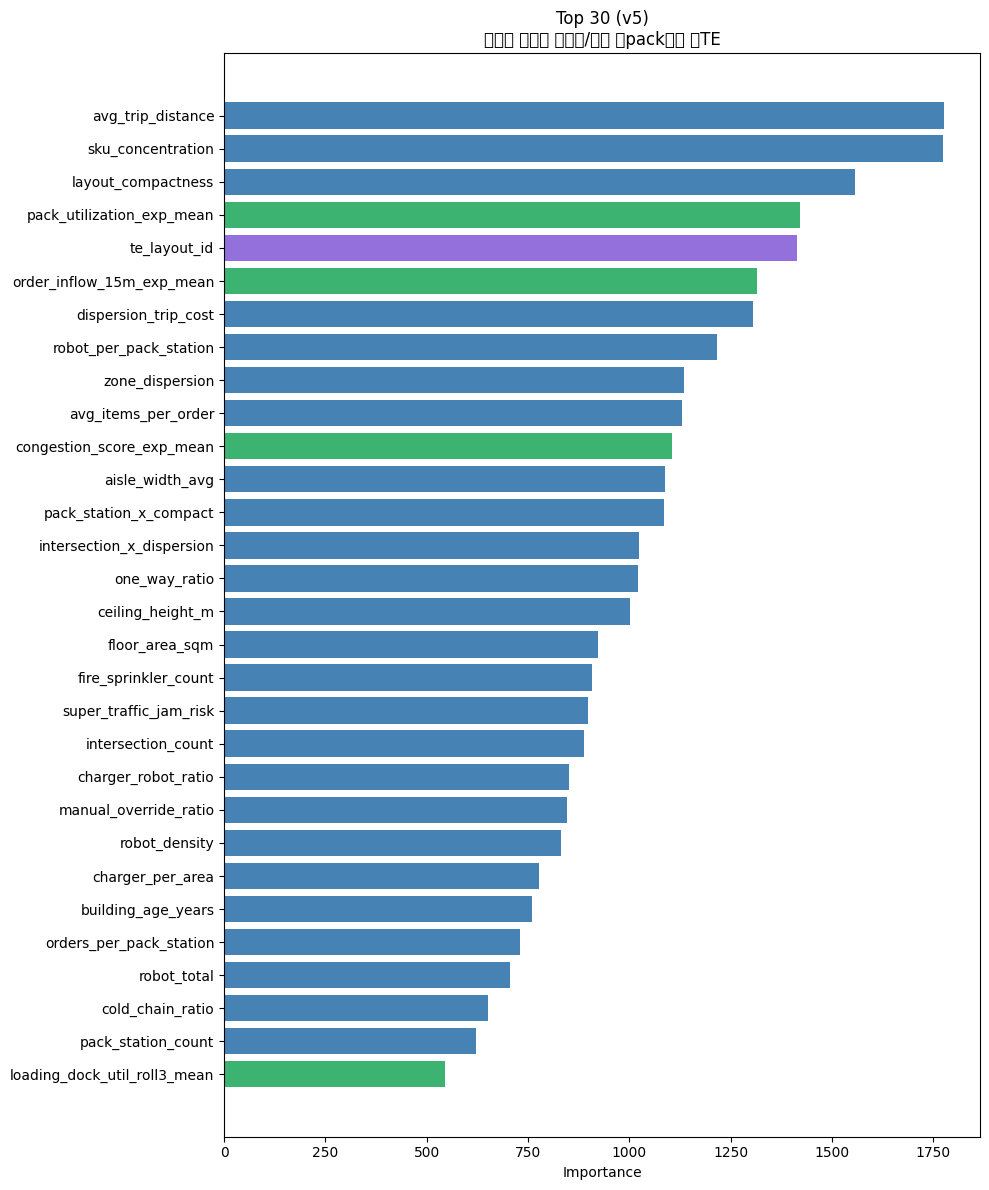

                  feature  importance
        avg_trip_distance      1776.2
        sku_concentration      1772.6
       layout_compactness      1555.6
pack_utilization_exp_mean      1421.6
             te_layout_id      1412.8
order_inflow_15m_exp_mean      1314.2
     dispersion_trip_cost      1305.2
   robot_per_pack_station      1216.6
          zone_dispersion      1134.6
      avg_items_per_order      1129.6
congestion_score_exp_mean      1104.2
          aisle_width_avg      1088.2
   pack_station_x_compact      1086.4
intersection_x_dispersion      1023.2
            one_way_ratio      1022.4


In [17]:
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': lgb_imp}).sort_values('importance', ascending=False).reset_index(drop=True)
top30 = imp_df.head(30)
def gc(n):
    if '_lag' in n or '_diff' in n: return 'coral'
    if any(t in n for t in ['_cumsum','_roll3','_exp_','_trend','slot_']): return 'mediumseagreen'
    if 'pack_sat' in n or 'pack_overflow' in n or 'pack_util_sq' in n: return 'gold'
    if 'te_' in n: return 'mediumpurple'
    return 'steelblue'
fig, ax = plt.subplots(figsize=(10,12))
ax.barh(top30['feature'][::-1], top30['importance'][::-1], color=top30['feature'].map(gc)[::-1])
ax.set_xlabel('Importance'); ax.set_title('Top 30 (v5)\n🔵원본 🟠래그 🟢누적/롤링 🟡pack임계 🟣TE')
plt.tight_layout(); plt.savefig('./feature_importance_v5.png', dpi=150, bbox_inches='tight'); plt.show()
print(imp_df.head(15)[['feature','importance']].to_string(index=False))

## 16. 제출

In [18]:
sub = pd.read_csv('./data/sample_submission.csv').drop(columns=[TARGET], errors='ignore')
sub = sub.merge(pd.DataFrame({'ID': test_fe['ID'], TARGET: final_preds}), on='ID', how='left')
sub.to_csv('./submission_v5.csv', index=False)
print('✅ submission_v5.csv 저장')
print(sub[TARGET].describe())
print(f'\n  v4 max ~51  → v5 max {final_preds.max():.1f}')
print(f'  v4 95% ~37  → v5 95% {np.percentile(final_preds,95):.1f}')
print(f'  v4 99% ~41  → v5 99% {np.percentile(final_preds,99):.1f}')

✅ submission_v5.csv 저장
count    50000.000000
mean        18.919585
std         13.641484
min          0.095448
25%          5.572095
50%         15.010507
75%         33.320160
max         69.740320
Name: avg_delay_minutes_next_30m, dtype: float64

  v4 max ~51  → v5 max 69.7
  v4 95% ~37  → v5 95% 38.4
  v4 99% ~41  → v5 99% 43.6
